# 📊 Dataset Information

**Note:** The dataset for this project is **not included in this repository** to keep the repository lightweight.  

You can download the dataset from **Kaggle** using the link below:  

[Download The Nepal Flood Weather Dataset](https://www.kaggle.com/datasets/tejal5kunjir/nepal-flood-and-weather-dataset-2023-2026)  

Please make sure to place the downloaded CSV file in the same directory as this notebook before running any code.

# Importing

## Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

/kaggle/input/datasets/tejal5kunjir/nepal-flood-and-weather-dataset-2023-2026/nepal_flood_weather_dataset_kaggle_2023_2026.csv


## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('nepal_flood_weather_dataset_kaggle_2023_2026.csv')

# Preprocessing

## Frist five row

In [3]:
df.head()

,date,location,river,basin,latitude,longitude,elevation_m,DHM Station,precipitation_mm,soil_moisture_0_100cm_m3m3,rain_mm,temperature_mean_c,dew_point_mean_c,precipitation_hours,relative_humidity_mean_pct,wind_speed_max_kmh,wind_gusts_max_kmh,wind_direction_dominant_deg,river_discharge_m3s
0,01-01-2023,Bahrabise,Bhote Koshi,Koshi,27.786773,85.899324,1870,610.0,0.0,0.0,0.0,0.291,12.3,6.8,71,7.8,24.1,106,1.05
1,01-01-2023,Belsot,Kamala,Kamala,26.912863,86.248330,188,595.5,0.0,0.0,0.0,0.223,15.2,11.3,79,7.1,16.6,9,12.09
2,01-01-2023,Bhada Bridge,Babai,Babai,28.188822,81.365650,157,291.0,0.0,0.0,0.0,0.258,12.4,10.2,87,11.1,12.2,300,0.31
3,01-01-2023,Chameliya/Nayalbadi,Chamelia,Mahakali,29.674420,80.562680,685,120.0,0.0,0.0,0.0,0.409,12.0,6.0,69,5.8,15.1,120,19.28
4,01-01-2023,Chatara,Saptakoshi,Koshi,26.855192,87.152283,153,695.0,0.3,0.3,3.0,0.217,15.8,10.7,73,8.0,18.7,1,0.26


## last Five row

In [4]:
df.tail()

,date,location,river,basin,latitude,longitude,elevation_m,DHM Station,precipitation_mm,soil_moisture_0_100cm_m3m3,rain_mm,temperature_mean_c,dew_point_mean_c,precipitation_hours,relative_humidity_mean_pct,wind_speed_max_kmh,wind_gusts_max_kmh,wind_direction_dominant_deg,river_discharge_m3s
13385,31-08-2026,Chisapani,Karnali,Karnali,28.653056,81.286944,2215,280.00,16.3,0.392,16.3,28.3,26.2,21.0,89,7.1,27.7,90,2.22
13386,31-08-2026,Devghat,Narayani,Narayani/Gandak,27.710000,84.430000,603,450.00,42.8,0.361,42.8,28.3,26.5,22.0,91,9.1,24.8,89,4.43
13387,31-08-2026,Khokana,Bagmati,Bagmati,27.632222,85.293333,1315,550.05,29.8,0.412,29.8,23.4,21.8,17.0,92,6.9,20.9,317,4.09
13388,31-08-2026,Kusum,West Rapti,Rapti,28.007500,82.093889,6367,375.00,20.3,0.419,20.3,27.7,26.3,18.0,93,9.6,28.8,87,621.30
13389,31-08-2026,Rasuwagadhi,Bhote Koshi,Narayani,28.271297,85.377649,1749,446.22,5.5,0.411,5.5,23.9,20.6,18.0,82,4.4,33.5,246,3.60


## Shape of our dataset

In [5]:
df.shape

(13390, 19)

## List out all columns

In [6]:
df.columns

Index(['date', 'location', 'river', 'basin', 'latitude', 'longitude',
       'elevation_m', 'DHM Station ', 'precipitation_mm',
       'soil_moisture_0_100cm_m3m3', 'rain_mm', 'temperature_mean_c',
       'dew_point_mean_c', 'precipitation_hours', 'relative_humidity_mean_pct',
       'wind_speed_max_kmh', 'wind_gusts_max_kmh',
       'wind_direction_dominant_deg', 'river_discharge_m3s'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

date                            object
location                        object
river                           object
basin                           object
latitude                       float64
longitude                      float64
elevation_m                      int64
DHM Station                    float64
precipitation_mm               float64
soil_moisture_0_100cm_m3m3     float64
rain_mm                        float64
temperature_mean_c             float64
dew_point_mean_c               float64
precipitation_hours            float64
relative_humidity_mean_pct       int64
wind_speed_max_kmh             float64
wind_gusts_max_kmh             float64
wind_direction_dominant_deg      int64
river_discharge_m3s            float64
dtype: object

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13390 entries, 0 to 13389
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   date                         13390 non-null  object 
 1   location                     13390 non-null  object 
 2   river                        13390 non-null  object 
 3   basin                        13390 non-null  object 
 4   latitude                     13390 non-null  float64
 5   longitude                    13390 non-null  float64
 6   elevation_m                  13390 non-null  int64  
 7   DHM Station                  13390 non-null  float64
 8   precipitation_mm             13390 non-null  float64
 9   soil_moisture_0_100cm_m3m3   13390 non-null  float64
 10  rain_mm                      13390 non-null  float64
 11  temperature_mean_c           13390 non-null  float64
 12  dew_point_mean_c             13390 non-null  float64
 13  precipitation_ho

## Check Null Value

In [9]:
df.isnull().sum()

date                           0
location                       0
river                          0
basin                          0
latitude                       0
longitude                      0
elevation_m                    0
DHM Station                    0
precipitation_mm               0
soil_moisture_0_100cm_m3m3     0
rain_mm                        0
temperature_mean_c             0
dew_point_mean_c               0
precipitation_hours            0
relative_humidity_mean_pct     0
wind_speed_max_kmh             0
wind_gusts_max_kmh             0
wind_direction_dominant_deg    0
river_discharge_m3s            0
dtype: int64

## Check Dupicate Value

In [10]:
df.duplicated().sum()

np.int64(0)

## Summary

In [11]:
df.describe()

,latitude,longitude,elevation_m,DHM Station,precipitation_mm,soil_moisture_0_100cm_m3m3,rain_mm,temperature_mean_c,dew_point_mean_c,precipitation_hours,relative_humidity_mean_pct,wind_speed_max_kmh,wind_gusts_max_kmh,wind_direction_dominant_deg,river_discharge_m3s
count,13390.000000,13390.000000,13390.000000,13390.000000,13390.000000,13390.000000,13390.000000,13390.000000,13390.000000,13390.000000,13390.000000,13390.000000,13390.000000,13390.000000,13390.000000
mean,27.969215,83.971008,1530.200000,441.277000,4.480344,1.256444,4.454048,16.168467,17.399574,7.614899,70.646079,9.939754,30.020097,171.362285,20.372064
std,0.780239,2.282525,1767.299867,168.756008,10.930667,5.228966,10.160051,10.996061,7.805372,8.094127,15.751117,4.013393,12.100016,105.259984,84.333629
min,26.855192,80.562680,153.000000,120.000000,0.000000,0.000000,0.000000,0.020000,-16.200000,-15.300000,12.000000,1.900000,10.400000,0.000000,0.000000
25%,27.632222,81.365650,188.000000,291.000000,0.000000,0.202000,0.000000,0.412000,11.700000,0.000000,60.000000,7.200000,21.600000,78.000000,0.260000
50%,27.897137,84.861667,1000.000000,448.110000,0.100000,0.309000,0.100000,18.600000,18.700000,5.000000,74.000000,9.100000,27.000000,172.000000,1.880000
75%,28.271297,85.899324,1870.000000,595.500000,4.200000,0.394000,5.000000,25.900000,23.900000,13.400000,83.000000,11.800000,34.600000,264.000000,10.530000
max,29.674420,87.152283,6367.000000,695.000000,343.700000,268.300000,343.700000,36.400000,36.100000,27.000000,100.000000,38.600000,114.100000,360.000000,3175.870000


# EDA

In [12]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

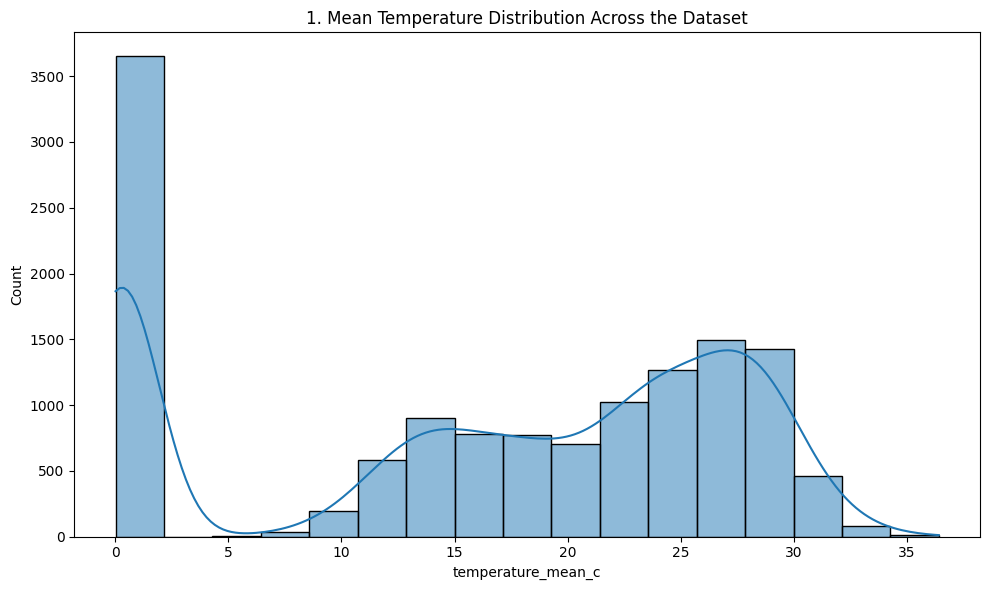

In [13]:
fig = plt.figure(figsize=(10,6))
sns.histplot(data=df, x='temperature_mean_c', kde=True)
plt.title(f'{plot_no}. Mean Temperature Distribution Across the Dataset')
show_fig()
plot_no += 1

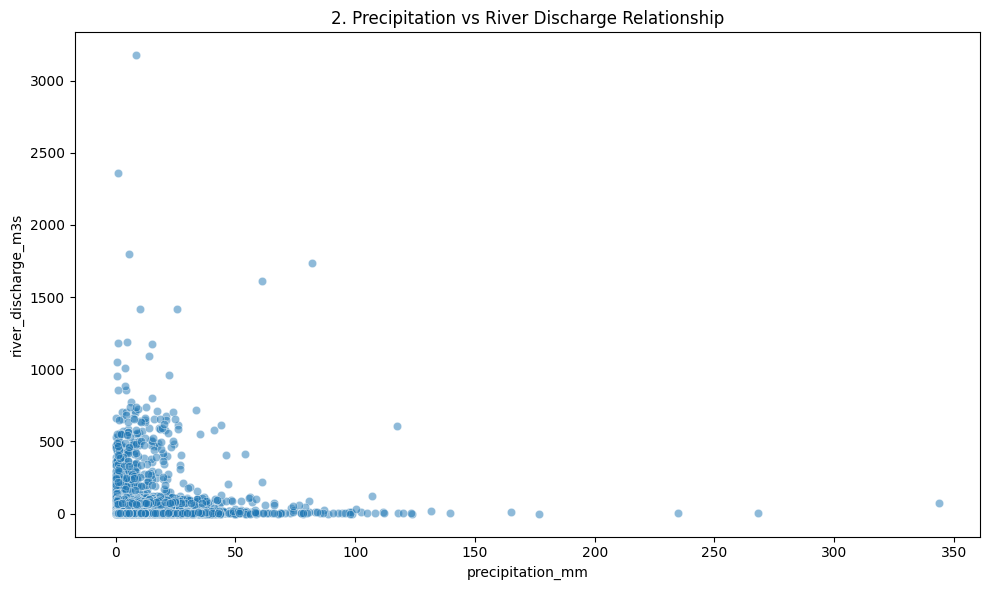

In [14]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='precipitation_mm', y='river_discharge_m3s', alpha=0.5)
plt.title(f'{plot_no}. Precipitation vs River Discharge Relationship')
show_fig()
plot_no += 1

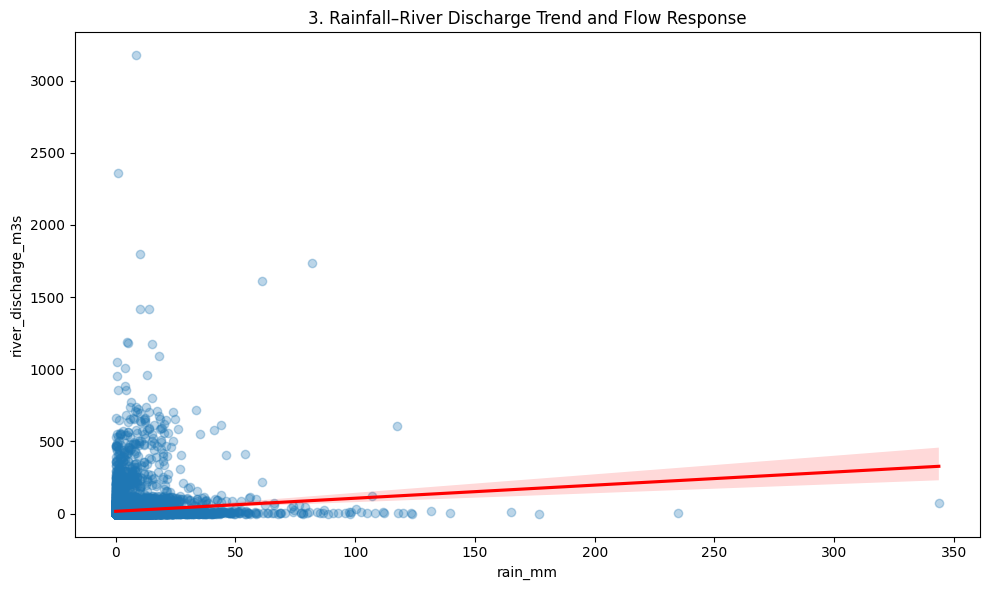

In [15]:
fig = plt.figure(figsize=(10,6))
sns.regplot(data=df, x='rain_mm', y='river_discharge_m3s', scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title(f'{plot_no}. Rainfall–River Discharge Trend and Flow Response')
show_fig()
plot_no += 1

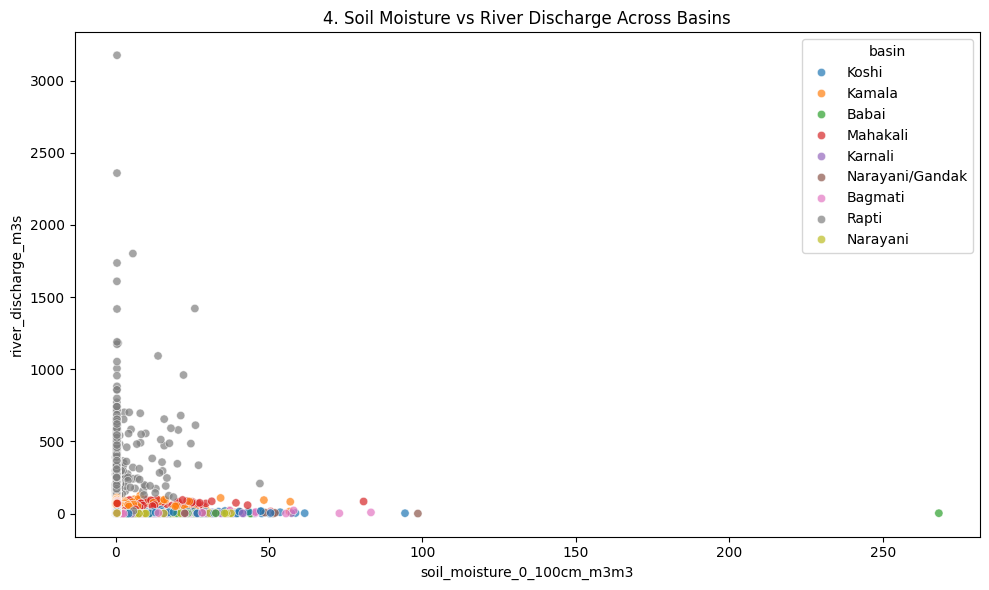

In [16]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='soil_moisture_0_100cm_m3m3', y='river_discharge_m3s', hue='basin', alpha=0.7)
plt.title(f'{plot_no}. Soil Moisture vs River Discharge Across Basins')
show_fig()
plot_no += 1

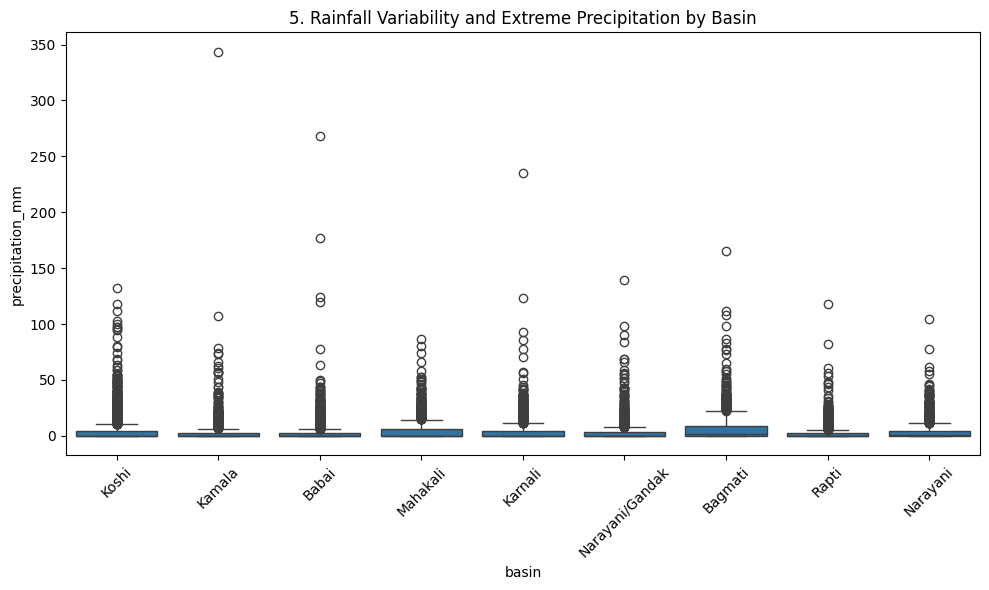

In [17]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='basin', y='precipitation_mm')
plt.xticks(rotation=45)
plt.title(f'{plot_no}. Rainfall Variability and Extreme Precipitation by Basin')
show_fig()
plot_no += 1

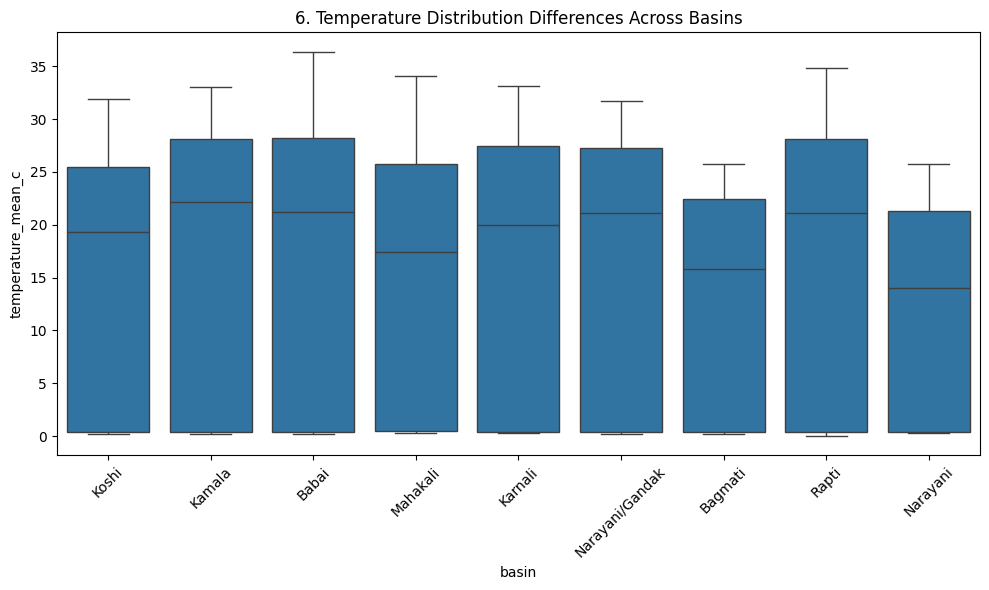

In [18]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='basin', y='temperature_mean_c')
plt.xticks(rotation=45)
plt.title(f'{plot_no}. Temperature Distribution Differences Across Basins')
show_fig()
plot_no += 1

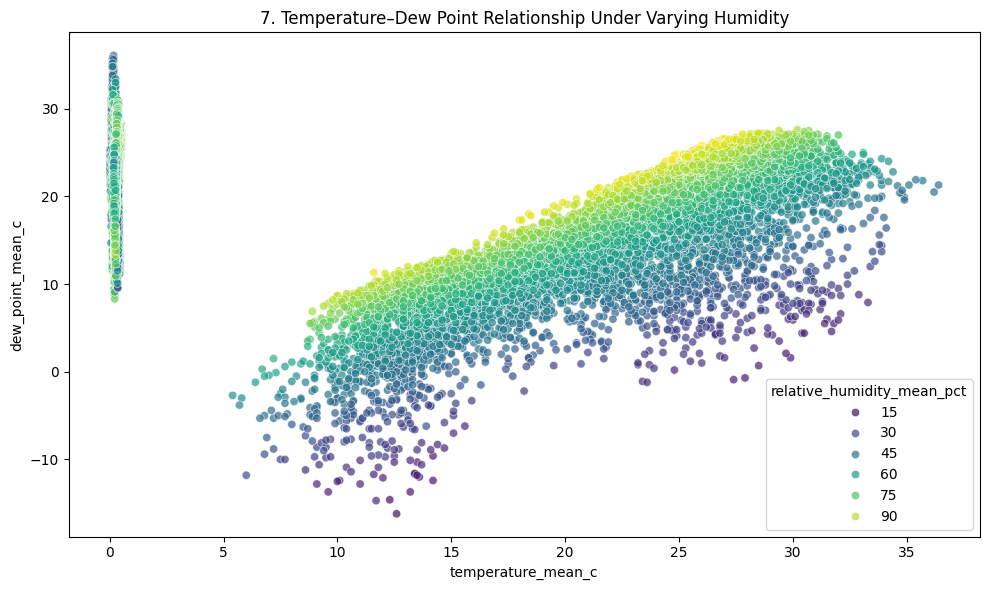

In [19]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='temperature_mean_c', y='dew_point_mean_c', hue='relative_humidity_mean_pct', palette='viridis', alpha=0.7)
plt.title(f'{plot_no}. Temperature–Dew Point Relationship Under Varying Humidity')
show_fig()
plot_no += 1

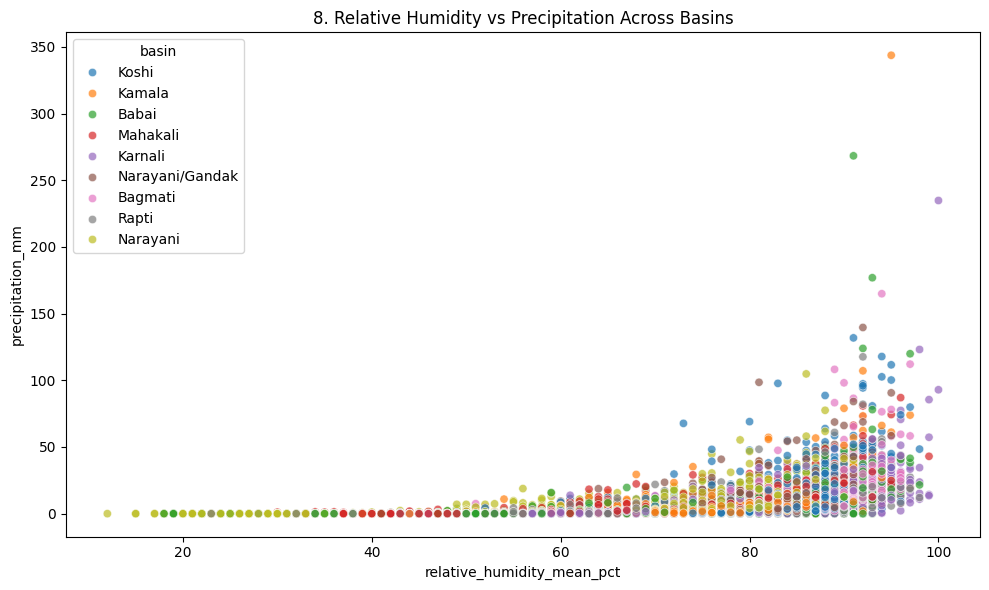

In [20]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='relative_humidity_mean_pct', y='precipitation_mm', hue='basin', alpha=0.7)
plt.title(f'{plot_no}. Relative Humidity vs Precipitation Across Basins')
show_fig()
plot_no += 1

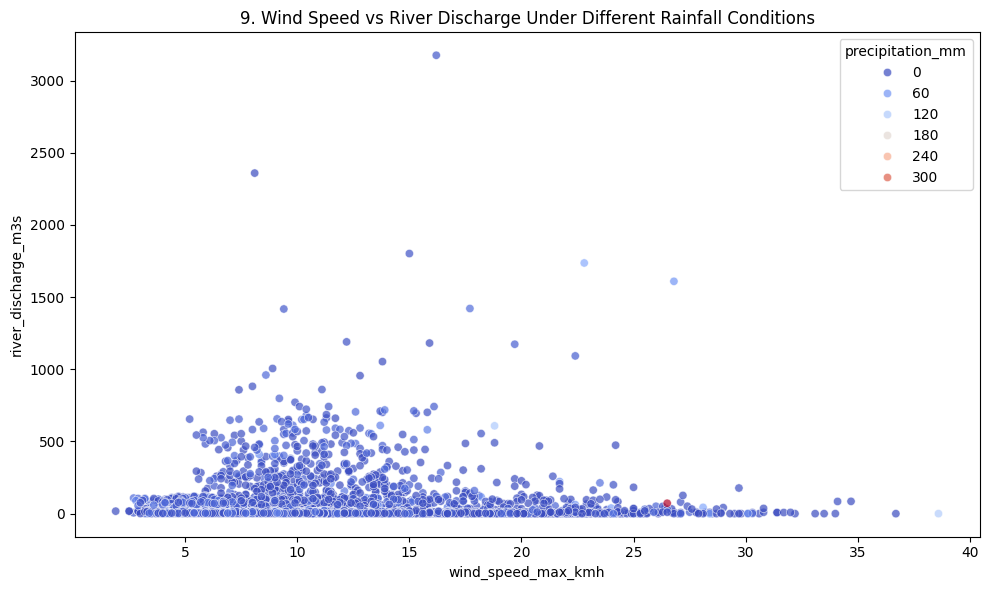

In [21]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='wind_speed_max_kmh', y='river_discharge_m3s', hue='precipitation_mm', palette='coolwarm', alpha=0.7)
plt.title(f'{plot_no}. Wind Speed vs River Discharge Under Different Rainfall Conditions')
show_fig()
plot_no += 1

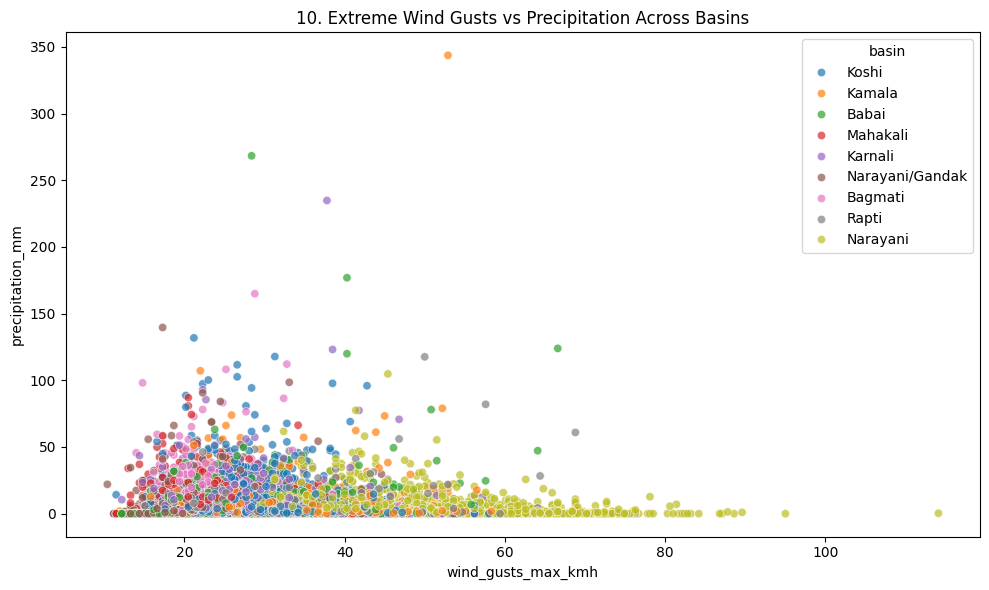

In [22]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='wind_gusts_max_kmh', y='precipitation_mm', hue='basin', alpha=0.7)
plt.title(f'{plot_no}. Extreme Wind Gusts vs Precipitation Across Basins')
show_fig()
plot_no += 1

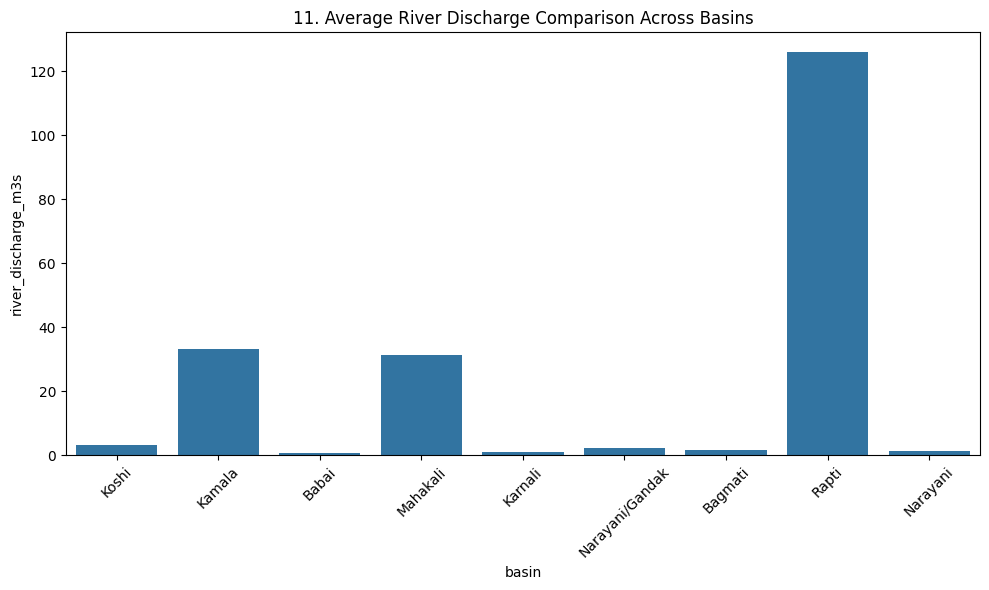

In [23]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='basin', y='river_discharge_m3s', estimator='mean', errorbar=None)
plt.xticks(rotation=45)
plt.title(f'{plot_no}. Average River Discharge Comparison Across Basins')
show_fig()
plot_no += 1

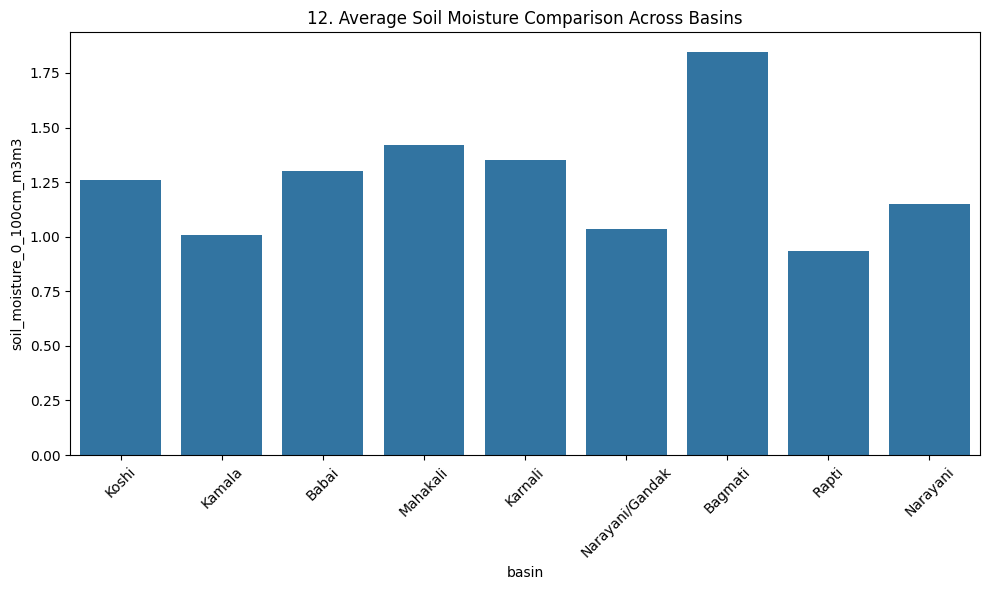

In [24]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='basin', y='soil_moisture_0_100cm_m3m3', estimator='mean', errorbar=None)
plt.xticks(rotation=45)
plt.title(f'{plot_no}. Average Soil Moisture Comparison Across Basins')
show_fig()
plot_no += 1

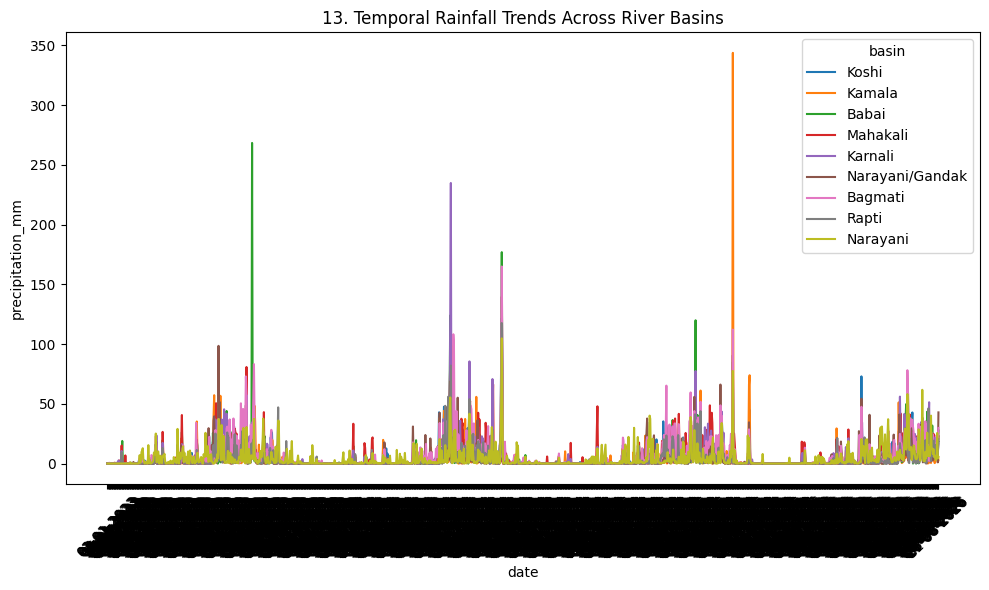

In [25]:
fig = plt.figure(figsize=(10,6))
sns.lineplot(data=df, x='date', y='precipitation_mm', hue='basin', estimator='mean', errorbar=None)
plt.xticks(rotation=45)
plt.title(f'{plot_no}. Temporal Rainfall Trends Across River Basins')
show_fig()
plot_no += 1

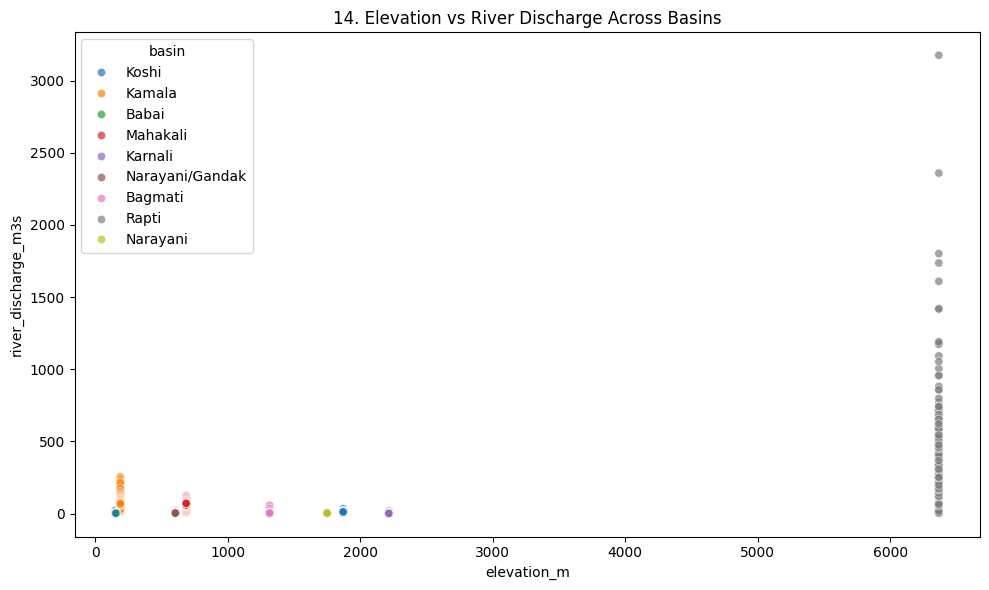

In [26]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='elevation_m', y='river_discharge_m3s', hue='basin', alpha=0.7)
plt.title(f'{plot_no}. Elevation vs River Discharge Across Basins')
show_fig()
plot_no += 1

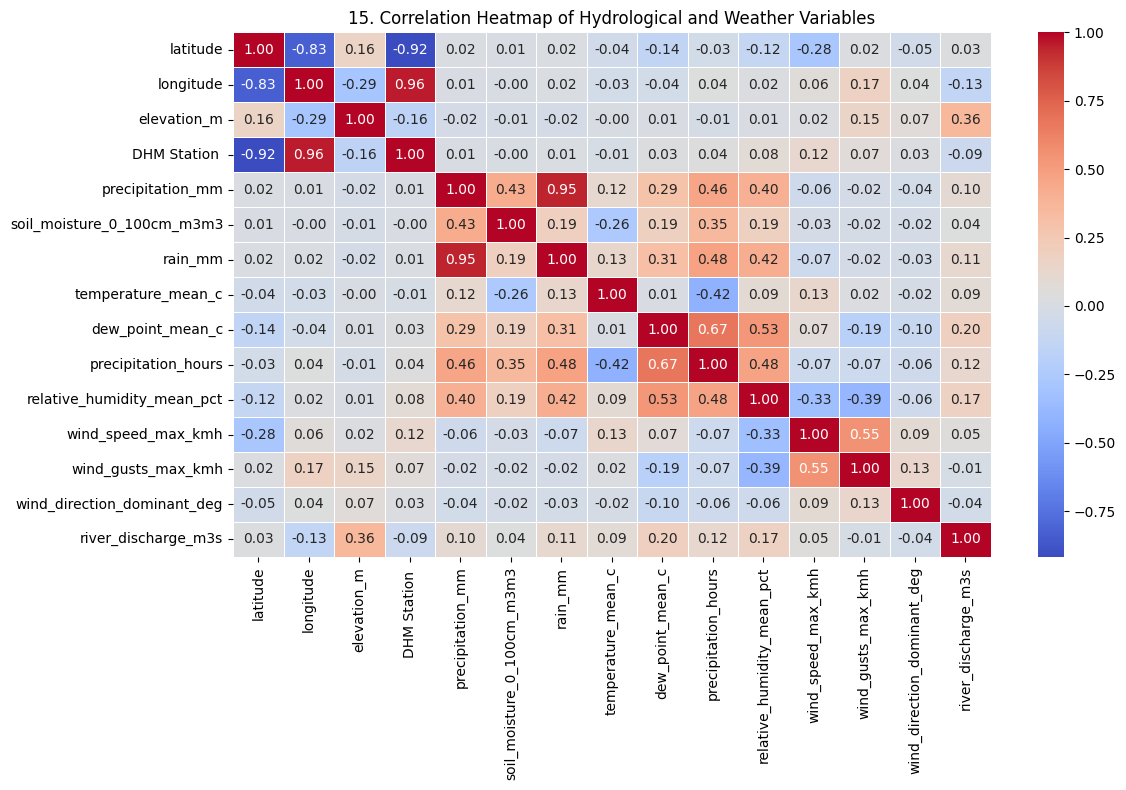

In [27]:
fig = plt.figure(figsize=(12,8))
corr = df.select_dtypes(include='number').corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title(f'{plot_no}. Correlation Heatmap of Hydrological and Weather Variables')
show_fig()
plot_no += 1

# Model Training

## Prepare features and target

In [29]:
target = 'river_discharge_m3s'

X = df.drop(columns=[target, 'date'], errors='ignore')
y = pd.to_numeric(df[target], errors='coerce')

## Remove invalid target values

In [30]:
valid = y.notna() & np.isfinite(y)
X = X.loc[valid]
y = y.loc[valid]

## Identify numerical and categorical columns

In [31]:
num_cols = X.select_dtypes(include=np.number).columns.tolist()
cat_cols = X.select_dtypes(exclude=np.number).columns.tolist()

## Handle missing values and encode categories

In [32]:
num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

## Combine preprocessing steps

In [33]:
preprocessor = ColumnTransformer([
    ('num', num_pipe, num_cols),
    ('cat', cat_pipe, cat_cols)
], remainder='drop')

## Split data into training and testing sets

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Build a supervised Extra Trees regression model

In [35]:
model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', ExtraTreesRegressor(
        n_estimators=150,
        min_samples_leaf=2,
        max_features=0.9,
        random_state=42,
        n_jobs=-1
    ))
])

## Train the model

In [36]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['latitude', 'longitude',
                                                   'elevation_m',
                                                   'DHM Station ',
                                                   'precipitation_mm',
                                                   'soil_moisture_0_100cm_m3m3',
                                                   'rain_mm',
                                                   'temperature_mean_c',
                                                   'dew_point_mean_c',
                                                   'precipitation_hours',
                                                   'relative_humidity_mean_pct',
                                                   'wind_speed_max_...,
                                                   'wind_gusts_max_kmh',
                                                   'wind_direction_dominant_deg']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['location', 'river',
                                                   'basin'])])),
                ('regressor',
                 ExtraTreesRegressor(max_features=0.9, min_samples_leaf=2,
                                     n_estimators=150, n_jobs=-1,
                                     random_state=42))])

## Predict river discharge

In [37]:
y_pred = model.predict(X_test)

## Evaluate model performance

In [38]:
print(f"R² Accuracy Score: {r2_score(y_test, y_pred):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")

R² Accuracy Score: 0.7220
MAE: 7.0670
RMSE: 47.8184


## Plot actual vs predicted river discharge

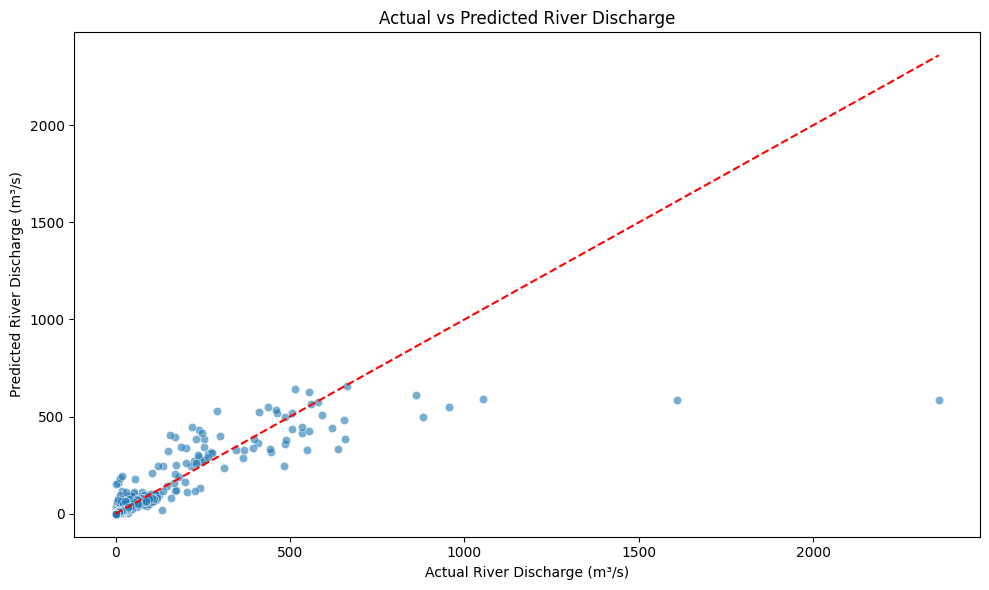

In [39]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--')
plt.xlabel('Actual River Discharge (m³/s)')
plt.ylabel('Predicted River Discharge (m³/s)')
plt.title('Actual vs Predicted River Discharge')
show_fig()